# <span style="font-width:bold; font-size: 3rem; color:#1EB182;"> **Air Quality** </span><span style="font-width:bold; font-size: 3rem; color:#333;">- Part 04: Batch Inference</span>

## 🗒️ This notebook is divided into the following sections:

1. Download model and batch inference data
2. Make predictions, generate PNG for forecast
3. Store predictions in a monitoring feature group adn generate PNG for hindcast

## <span style='color:#ff5f27'> 📝 Imports

In [24]:
import sys
from pathlib import Path

def is_google_colab() -> bool:
    if "google.colab" in str(get_ipython()):
        return True
    return False

def clone_repository() -> None:
    !git clone https://github.com/featurestorebook/mlfs-book.git
    %cd mlfs-book

def install_dependencies() -> None:
    !pip install --upgrade uv
    !uv pip install --all-extras --system --requirement pyproject.toml


if is_google_colab():
    clone_repository()
    install_dependencies()
    root_dir = str(Path().absolute())
    print("Google Colab environment")
else:
    root_dir = Path().absolute()
    # Strip ~/notebooks/ccfraud from PYTHON_PATH if notebook started in one of these subdirectories
    if root_dir.parts[-1:] == ('airquality',):
        root_dir = Path(*root_dir.parts[:-1])
    if root_dir.parts[-1:] == ('notebooks',):
        root_dir = Path(*root_dir.parts[:-1])
    root_dir = str(root_dir) 
    print("Local environment")

# Add the root directory to the `PYTHONPATH` to use the `recsys` Python module from the notebook.
if root_dir not in sys.path:
    sys.path.append(root_dir)
print(f"Added the following directory to the PYTHONPATH: {root_dir}")
    
# Read the API keys and configuration variables from the file <root_dir>/.env
# from mlfs import config
# settings = config.HopsworksSettings(_env_file=f"{root_dir}/.env")

Local environment
Added the following directory to the PYTHONPATH: /home/lukasfri/Repositories/github.com/GeorgesTohme/mlfs-book


In [25]:
import datetime
import pandas as pd
from xgboost import XGBRegressor
import hopsworks
import json
from mlfs.airquality import util
import os

In [26]:
today = datetime.datetime.now() - datetime.timedelta(0)
tomorrow = today + datetime.timedelta(days = 1)
yesterday = today - datetime.timedelta(days = 1)
today

datetime.datetime(2025, 11, 18, 16, 44, 27, 787060)

## <span style="color:#ff5f27;"> 📡 Connect to Hopsworks Feature Store </span>

In [27]:
from dotenv import load_dotenv

load_dotenv(dotenv_path=f"{root_dir}/.env", override=True)

print(f"{root_dir}/.env")

import os

/home/lukasfri/Repositories/github.com/GeorgesTohme/mlfs-book/.env


In [28]:
project = hopsworks.login(engine="python")
fs = project.get_feature_store() 

secrets = hopsworks.get_secrets_api()
city = os.getenv("AQICN_CITY")
print(f"Using city: {city}")
location_str = secrets.get_secret(f"SENSOR_LOCATION_JSON_{city}").value
location = json.loads(location_str)
country=location['country']
city=location['city']
street=location['street']

2025-11-18 16:44:27,828 INFO: Closing external client and cleaning up certificates.
Connection closed.
2025-11-18 16:44:27,830 INFO: Initializing external client
2025-11-18 16:44:27,830 INFO: Base URL: https://c.app.hopsworks.ai:443
2025-11-18 16:44:28,293 WARNING: UserWarning: The installed hopsworks client version 4.1.4 may not be compatible with the connected Hopsworks backend version 4.2.2. 
To ensure compatibility please install the latest bug fix release matching the minor version of your backend (4.2) by running 'pip install hopsworks==4.2.*'



2025-11-18 16:44:29,038 INFO: Python Engine initialized.

Logged in to project, explore it here https://c.app.hopsworks.ai:443/p/1279130
Using city: Nora


## <span style="color:#ff5f27;">🪝 Download the model from Model Registry</span>

In [29]:
mr = project.get_model_registry()

retrieved_model = mr.get_model(
    name="air_quality_xgboost_model",
    version=1,
)

fv = retrieved_model.get_feature_view()

# Download the saved model artifacts to a local directory
saved_model_dir = retrieved_model.download()

In [30]:
# Loading the XGBoost regressor model and label encoder from the saved model directory
# retrieved_xgboost_model = joblib.load(saved_model_dir + "/xgboost_regressor.pkl")
retrieved_xgboost_model = XGBRegressor()

retrieved_xgboost_model.load_model(saved_model_dir + "/model.json")

# Displaying the retrieved XGBoost regressor model
retrieved_xgboost_model

XGBRegressor(base_score='5.5655355E0', booster='gbtree', callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None,
             feature_types=['float', 'float', 'float', 'float', 'float',
                            'float', 'float'],
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

## <span style="color:#ff5f27;">✨ Get Weather Forecast Features with Feature View   </span>



In [31]:
weather_fg = fs.get_feature_group(
    name='weather',
    version=1,
)
# batch_data = weather_fg.filter((weather_fg.date >= today) & (weather_fg.city == city)).read()

# Hopsworks contains a bug with Ö-character
# Since currently we only have Nora and Örebro, filter Örebro by not being Nora
# Filter to just be tomorrow's weather
cond = weather_fg.city == "Nora" if city == "Nora" else weather_fg.city != "Nora"
next_day_data = weather_fg.filter((weather_fg.date > today) & cond).filter(weather_fg.date <= tomorrow).read()
next_day_data

Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (0.94s) 


,date,temperature_2m_mean,precipitation_sum,wind_speed_10m_max,wind_direction_10m_dominant,city
0,2025-11-19 00:00:00+00:00,-3.45,0.0,4.693826,57.528828,Nora


### Adding the Lagged Air Quality to the Inference Data

In [32]:
aq_fg = fs.get_feature_group(
    name='air_quality',
    version=1
)
lagged_aq = aq_fg.filter(aq_fg.date <= today).filter(aq_fg.date > yesterday).read()
lagged_aq
prev_aq = pd.DataFrame()
prev_aq['date'] = lagged_aq['date'] + datetime.timedelta(days=1)
prev_aq['pm25_lag_1'] = lagged_aq['pm25']
prev_aq['pm25_lag_2'] = lagged_aq['pm25_lag_1']
prev_aq['pm25_lag_3'] = lagged_aq['pm25_lag_2']

prev_aq

batch_data = pd.merge(next_day_data, prev_aq, on='date')
batch_data

Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (1.01s) 


,date,temperature_2m_mean,precipitation_sum,wind_speed_10m_max,wind_direction_10m_dominant,city,pm25_lag_1,pm25_lag_2,pm25_lag_3
0,2025-11-19 00:00:00+00:00,-3.45,0.0,4.693826,57.528828,Nora,14.0,14.0,14.0
1,2025-11-19 00:00:00+00:00,-3.45,0.0,4.693826,57.528828,Nora,8.0,8.0,8.0


### <span style="color:#ff5f27;">🤖 Making the predictions</span>

In [33]:
batch_data['predicted_pm25'] = retrieved_xgboost_model.predict(
    batch_data[['pm25_lag_1', 'pm25_lag_2', 'pm25_lag_3', 'temperature_2m_mean', 'precipitation_sum', 'wind_speed_10m_max', 'wind_direction_10m_dominant']])
batch_data

,date,temperature_2m_mean,precipitation_sum,wind_speed_10m_max,wind_direction_10m_dominant,city,pm25_lag_1,pm25_lag_2,pm25_lag_3,predicted_pm25
0,2025-11-19 00:00:00+00:00,-3.45,0.0,4.693826,57.528828,Nora,14.0,14.0,14.0,4.365627
1,2025-11-19 00:00:00+00:00,-3.45,0.0,4.693826,57.528828,Nora,8.0,8.0,8.0,4.313728


### Looping Through the Weather Predictions to Predict the Air Quality

In [34]:
weather_data = weather_fg.filter(weather_fg.date > tomorrow).read()
days_to_perdict = len(weather_data)

for i in range(days_to_perdict):
    next_aq = pd.DataFrame()
    next_aq['date'] = batch_data.tail(1)['date'] + datetime.timedelta(days=1)
    next_aq['pm25_lag_1'] = batch_data.tail(1)['predicted_pm25']
    next_aq['pm25_lag_2'] = batch_data.tail(1)['pm25_lag_1']
    next_aq['pm25_lag_3'] = batch_data.tail(1)['pm25_lag_2']

    next_data_row = pd.merge(next_aq, weather_data, on='date').drop(columns=['city'])
    next_data_row['predicted_pm25'] = retrieved_xgboost_model.predict(
    next_data_row[['pm25_lag_1', 'pm25_lag_2', 'pm25_lag_3', 'temperature_2m_mean', 'precipitation_sum', 'wind_speed_10m_max', 'wind_direction_10m_dominant']])

    batch_data = pd.concat([batch_data, next_data_row], ignore_index=True)

batch_data


Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (0.87s) 


ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 0, the array at index 0 has size 1 and the array at index 1 has size 0

In [ ]:
batch_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype                  
---  ------                       --------------  -----                  
 0   date                         6 non-null      datetime64[us, Etc/UTC]
 1   temperature_2m_mean          6 non-null      float32                
 2   precipitation_sum            6 non-null      float32                
 3   wind_speed_10m_max           6 non-null      float32                
 4   wind_direction_10m_dominant  6 non-null      float32                
 5   city                         1 non-null      object                 
 6   pm25_lag_1                   6 non-null      float32                
 7   pm25_lag_2                   6 non-null      float32                
 8   pm25_lag_3                   6 non-null      float32                
 9   predicted_pm25               6 non-null      float32                
dtypes: dat

### <span style="color:#ff5f27;">🤖 Saving the predictions (for monitoring) to a Feature Group</span>

In [ ]:
batch_data['street'] = street
batch_data['city'] = city
batch_data['country'] = country
# Fill in the number of days before the date on which you made the forecast (base_date)
batch_data['days_before_forecast_day'] = range(1, len(batch_data)+1)
batch_data = batch_data.sort_values(by=['date'])
batch_data

,date,temperature_2m_mean,precipitation_sum,wind_speed_10m_max,wind_direction_10m_dominant,city,pm25_lag_1,pm25_lag_2,pm25_lag_3,predicted_pm25,street,country,days_before_forecast_day
0,2025-11-19 00:00:00+00:00,-3.00,0.0,5.495161,31.607454,Örebro,14.000000,14.000000,14.000000,4.365627,Kungsgatan,sweden,1
1,2025-11-20 00:00:00+00:00,-2.10,0.0,15.379206,16.313938,Örebro,4.365627,14.000000,14.000000,2.515052,Kungsgatan,sweden,2
2,2025-11-21 00:00:00+00:00,-1.80,0.0,10.883676,325.784241,Örebro,2.515052,4.365627,14.000000,1.439316,Kungsgatan,sweden,3
3,2025-11-22 00:00:00+00:00,2.00,0.0,17.317459,226.684647,Örebro,1.439316,2.515052,4.365627,2.439035,Kungsgatan,sweden,4
4,2025-11-23 00:00:00+00:00,2.85,0.0,11.808878,217.568665,Örebro,2.439035,1.439316,2.515052,3.039634,Kungsgatan,sweden,5
5,2025-11-24 00:00:00+00:00,1.70,0.0,9.227524,20.556128,Örebro,3.039634,2.439035,1.439316,3.685446,Kungsgatan,sweden,6


In [ ]:
batch_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype                  
---  ------                       --------------  -----                  
 0   date                         6 non-null      datetime64[us, Etc/UTC]
 1   temperature_2m_mean          6 non-null      float32                
 2   precipitation_sum            6 non-null      float32                
 3   wind_speed_10m_max           6 non-null      float32                
 4   wind_direction_10m_dominant  6 non-null      float32                
 5   city                         6 non-null      object                 
 6   pm25_lag_1                   6 non-null      float32                
 7   pm25_lag_2                   6 non-null      float32                
 8   pm25_lag_3                   6 non-null      float32                
 9   predicted_pm25               6 non-null      float32                
 10  street

### Create Forecast Graph
Draw a graph of the predictions with dates as a PNG and save it to the github repo
Show it on github pages

2025-11-18 16:32:36,278 WARNING: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.



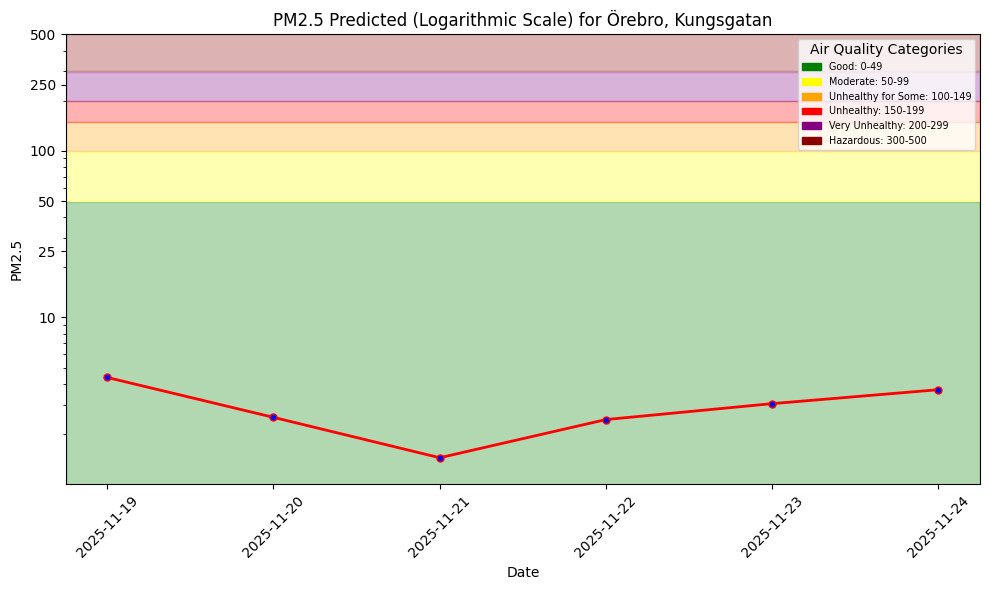

In [ ]:

pred_file_path = f"{root_dir}/docs/air-quality/assets/img/pm25_forecast_{city}.png"
plt = util.plot_air_quality_forecast(city, street, batch_data, pred_file_path)

plt.show()

In [ ]:
# Get or create feature group
monitor_fg = fs.get_or_create_feature_group(
    name='aq_predictions',
    description='Air Quality prediction monitoring',
    version=1,
    primary_key=['city','street','date','days_before_forecast_day'],
    event_time="date"
)

In [ ]:
monitor_fg.insert(batch_data, wait=True)

Uploading Dataframe: 100.00% |██████████| Rows 6/6 | Elapsed Time: 00:01 | Remaining Time: 00:00


Launching job: aq_predictions_1_offline_fg_materialization
Job started successfully, you can follow the progress at 
https://c.app.hopsworks.ai:443/p/1279130/jobs/named/aq_predictions_1_offline_fg_materialization/executions
2025-11-18 16:32:53,425 INFO: Waiting for execution to finish. Current state: SUBMITTED. Final status: UNDEFINED
2025-11-18 16:32:56,586 INFO: Waiting for execution to finish. Current state: RUNNING. Final status: UNDEFINED
2025-11-18 16:34:47,234 INFO: Waiting for execution to finish. Current state: AGGREGATING_LOGS. Final status: SUCCEEDED
2025-11-18 16:34:47,385 INFO: Waiting for log aggregation to finish.
2025-11-18 16:35:12,402 INFO: Execution finished successfully.


(Job('aq_predictions_1_offline_fg_materialization', 'SPARK'), None)

In [ ]:
# We will create a hindcast chart for  only the forecasts made 1 day beforehand
# Since currently we only have Nora and Örebro, filter Örebro by not being Nora
cond = monitor_fg.city == "Nora" if city == "Nora" else monitor_fg.city != "Nora"
monitoring_df = monitor_fg.filter(monitor_fg.days_before_forecast_day == 1).filter(cond).read()
monitoring_df

Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (1.06s) 


,date,temperature_2m_mean,precipitation_sum,wind_speed_10m_max,wind_direction_10m_dominant,city,pm25_lag_1,pm25_lag_2,pm25_lag_3,predicted_pm25,street,country,days_before_forecast_day
0,2025-11-19 00:00:00+00:00,-3.0,0.0,5.495161,31.607454,Örebro,14.0,14.0,14.0,4.365627,Kungsgatan,sweden,1


In [ ]:
air_quality_fg = fs.get_feature_group(name='air_quality', version=1)
air_quality_df = air_quality_fg.read()
air_quality_df

Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (0.83s) 


,date,pm25,pm25_lag_1,pm25_lag_2,pm25_lag_3,country,city,street,url
0,2025-08-15 00:00:00+00:00,10.08,5.64,4.51,3.57,sweden,Örebro,Kungsgatan,https://api.waqi.info/feed/A547147
1,2025-07-25 00:00:00+00:00,7.02,12.26,10.51,11.15,sweden,Örebro,Kungsgatan,https://api.waqi.info/feed/A547147
2,2025-08-22 00:00:00+00:00,1.38,1.84,1.52,2.17,sweden,Örebro,Kungsgatan,https://api.waqi.info/feed/A547147
3,2025-07-14 00:00:00+00:00,8.90,10.21,8.63,5.92,sweden,Örebro,Kungsgatan,https://api.waqi.info/feed/A547147
4,2025-11-01 00:00:00+00:00,2.14,0.96,1.86,3.54,sweden,Örebro,Kungsgatan,https://api.waqi.info/feed/A547147
...,...,...,...,...,...,...,...,...,...
130,2025-09-06 00:00:00+00:00,4.94,5.52,4.58,4.13,sweden,Örebro,Kungsgatan,https://api.waqi.info/feed/A547147
131,2025-09-22 00:00:00+00:00,1.05,6.25,4.16,5.65,sweden,Örebro,Kungsgatan,https://api.waqi.info/feed/A547147
132,2025-09-08 00:00:00+00:00,6.94,4.78,4.94,5.52,sweden,Örebro,Kungsgatan,https://api.waqi.info/feed/A547147
133,2025-10-26 00:00:00+00:00,3.84,3.74,5.63,6.43,sweden,Örebro,Kungsgatan,https://api.waqi.info/feed/A547147


In [ ]:
outcome_df = air_quality_df[['date', 'pm25', 'pm25_lag_1', 'pm25_lag_2', 'pm25_lag_3']]
preds_df =  monitoring_df[['date', 'predicted_pm25']]

hindcast_df = pd.merge(preds_df, outcome_df, on="date")
hindcast_df = hindcast_df.sort_values(by=['date'])

hindcast_df

,date,predicted_pm25,pm25,pm25_lag_1,pm25_lag_2,pm25_lag_3


In [ ]:

# If there are no outcomes for predictions yet, generate some predictions/outcomes from existing data
if len(hindcast_df) == 0:
    hindcast_df = util.backfill_predictions_for_monitoring_with_lagged_aq(weather_fg, air_quality_df, monitor_fg, retrieved_xgboost_model)
hindcast_df

Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (0.53s) 


Uploading Dataframe: 100.00% |██████████| Rows 10/10 | Elapsed Time: 00:01 | Remaining Time: 00:00


Launching job: aq_predictions_1_offline_fg_materialization
Job started successfully, you can follow the progress at 
https://c.app.hopsworks.ai:443/p/1279130/jobs/named/aq_predictions_1_offline_fg_materialization/executions
2025-11-18 16:35:33,892 INFO: Waiting for execution to finish. Current state: SUBMITTED. Final status: UNDEFINED
2025-11-18 16:35:37,057 INFO: Waiting for execution to finish. Current state: RUNNING. Final status: UNDEFINED
2025-11-18 16:36:59,293 INFO: Waiting for execution to finish. Current state: AGGREGATING_LOGS. Final status: SUCCEEDED
2025-11-18 16:36:59,435 INFO: Waiting for log aggregation to finish.
2025-11-18 16:37:07,951 INFO: Execution finished successfully.


,date,temperature_2m_mean,precipitation_sum,wind_speed_10m_max,wind_direction_10m_dominant,city,pm25_lag_1,pm25_lag_2,pm25_lag_3,predicted_pm25,pm25,street,country,days_before_forecast_day
0,2025-11-09 00:00:00+00:00,6.444417,0.4,12.065372,248.738617,Örebro,2.69,6.33,5.07,3.484612,6.19,Kungsgatan,sweden,1
1,2025-11-10 00:00:00+00:00,6.159000,1.2,7.229191,89.809029,Örebro,6.19,2.69,6.33,4.056185,3.22,Kungsgatan,sweden,1
2,2025-11-11 00:00:00+00:00,6.550666,0.0,11.633348,185.059341,Örebro,3.22,6.19,2.69,3.400454,4.41,Kungsgatan,sweden,1
3,2025-11-12 00:00:00+00:00,8.723582,6.3,31.154043,205.301010,Örebro,4.41,3.22,6.19,3.166301,3.23,Kungsgatan,sweden,1
4,2025-11-13 00:00:00+00:00,6.344417,8.0,28.757780,263.844116,Örebro,3.23,4.41,3.22,1.916437,1.37,Kungsgatan,sweden,1
5,2025-11-14 00:00:00+00:00,-0.984750,0.0,14.096425,277.026306,Örebro,1.37,3.23,4.41,1.770545,1.95,Kungsgatan,sweden,1
6,2025-11-15 00:00:00+00:00,-1.253500,0.0,20.035059,246.759659,Örebro,1.95,1.37,3.23,2.419262,1.74,Kungsgatan,sweden,1
7,2025-11-16 00:00:00+00:00,-0.620167,0.0,16.084589,254.453964,Örebro,1.74,1.95,1.37,1.502389,1.86,Kungsgatan,sweden,1
8,2025-11-17 00:00:00+00:00,-3.743083,0.0,10.486448,316.213623,Örebro,1.86,1.74,1.95,1.345850,2.63,Kungsgatan,sweden,1
9,2025-11-18 00:00:00+00:00,-2.000000,0.0,1.800000,270.000000,Örebro,14.00,14.00,14.00,2.506282,14.00,Kungsgatan,sweden,1


### Plot the Hindcast comparing predicted with forecasted values (1-day prior forecast)

__This graph will be empty to begin with - this is normal.__

After a few days of predictions and observations, you will get data points in this graph.

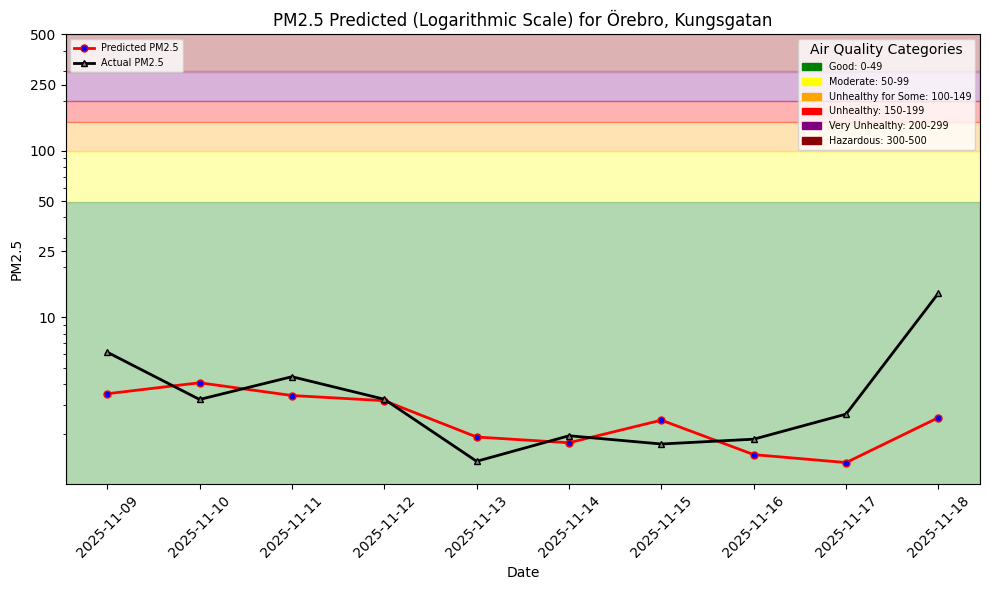

In [ ]:
hindcast_file_path = f"{root_dir}/docs/air-quality/assets/img/pm25_hindcast_1day_{city}.png"
plt = util.plot_air_quality_forecast(city, street, hindcast_df, hindcast_file_path, hindcast=True)
plt.show()

### Upload the prediction and hindcast dashboards (png files) to Hopsworks


In [ ]:
dataset_api = project.get_dataset_api()
str_today = today.strftime("%Y-%m-%d")
if dataset_api.exists("Resources/airquality") == False:
    dataset_api.mkdir("Resources/airquality")
dataset_api.upload(pred_file_path, f"Resources/airquality/{city}_{street}_{str_today}", overwrite=True)
dataset_api.upload(hindcast_file_path, f"Resources/airquality/{city}_{street}_{str_today}", overwrite=True)

proj_url = project.get_url()
print(f"See images in Hopsworks here: {proj_url}/settings/fb/path/Resources/airquality")

Uploading: 0.000%|          | 0/47024 elapsed<00:00 remaining<?

Uploading: 0.000%|          | 0/62804 elapsed<00:00 remaining<?

See images in Hopsworks here: https://c.app.hopsworks.ai:443/p/1279130/settings/fb/path/Resources/airquality


---